In [6]:
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import LinearSVC
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('clean_comments.csv').dropna(subset=['clean_comment']).dropna()
df = df.drop(columns=['Unnamed: 0'])
df.head()

,clean_comment,category
0,family mormon have never tried explain them th...,2
1,buddhism has very much lot compatible with chr...,2
2,seriously don say thing first all they won get...,0
3,what you have learned yours and only yours wha...,1
4,for your own benefit you may want read living ...,2


In [4]:
ngram_range = (1, 3)
max_features = 400

X_train, X_test, y_train, y_test = train_test_split(df['clean_comment'], df['category'], test_size=0.2, random_state=42, stratify=df['category'])
vectorizer = CountVectorizer(ngram_range=ngram_range, max_features=max_features)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

smote = SMOTE(random_state=42)
X_train_vec, y_train = smote.fit_resample(X_train_vec, y_train)

In [5]:
#Base Learners:
XG_params = {'n_estimators': 836, 'max_depth': 10, 'learning_rate': 0.1256404693880449, 'subsample': 0.7318445076214032, 'colsample_bytree': 0.9071567573862568, 'gamma': 0.40961503669078303, 'min_child_weight': 8, 'reg_alpha': 0.0015323739453981752, 'reg_lambda': 2.9525294221316316}
XGBoost_Model = XGBClassifier(**XG_params)

Log_Reg_model = LogisticRegression(
        max_iter=1000,
        random_state=42
    )

linsvc_model = LinearSVC(random_state=42)

In [9]:
stacking_model = StackingClassifier(
    estimators = [
        ("XGBoost", XGBoost_Model),
        ("logistic_regression",Log_Reg_model),
        ("linear_SVC", linsvc_model)
    ],
    final_estimator = LogisticRegression(),
    cv = 5
)

In [10]:
stacking_model.fit(X_train_vec, y_train)

StackingClassifier(cv=5,
                   estimators=[('XGBoost',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=0.9071567573862568,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric=None,
                                              feature_types=None,
                                              feature_weights=None,
                                              gamma=0.40961503669078303,
                                              grow_policy=None,...
                                              max_cat_to_onehot=None,
                                              max_delta_step=None, max_depth=10,
                                              max_leaves=None,
                                              min_child_weight=8, missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=836, n_jobs=None,
                                              num_parallel_tree=None, ...)),
                               ('logistic_regression',
                                LogisticRegression(max_iter=1000,
                                                   random_state=42)),
                               ('linear_SVC', LinearSVC(random_state=42))],
                   final_estimator=LogisticRegression())

0.7173852829840274
              precision    recall  f1-score   support

           0       0.57      0.46      0.51      2109
           1       0.66      0.82      0.73      3379
           2       0.82      0.75      0.78      5343

    accuracy                           0.72     10831
   macro avg       0.68      0.68      0.68     10831
weighted avg       0.72      0.72      0.71     10831



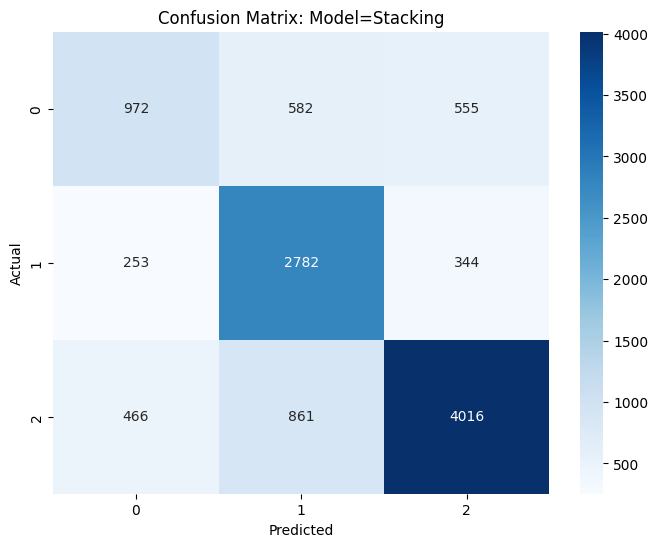

In [11]:
y_pred = stacking_model.predict(X_test_vec)

print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix: Model=Stacking")
plt.show()